In [36]:
"""
Import required libraries
"""

%load_ext autoreload
%autoreload 2

import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np

from src.mh import *
from src.util import *
from src.pf import *
from src.ssm import *
from src.hi_smc import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


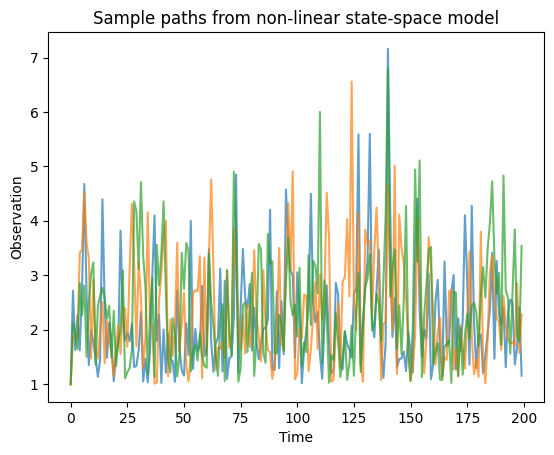

In [33]:
"""
Non-linear state-space model test / debug run
"""

T = 200
rng = np.random.default_rng(seed=42)
u = rng.normal(loc=0, scale=1, size=T)
theta = np.asarray([1,1])

n_paths = 3

for _ in range(n_paths):
    xs, ys = Svensson2017NonLinearSSM_simulate(u, theta, T, rng)
    plt.plot(ys, alpha=0.7)
    

plt.title("Sample paths from non-linear state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

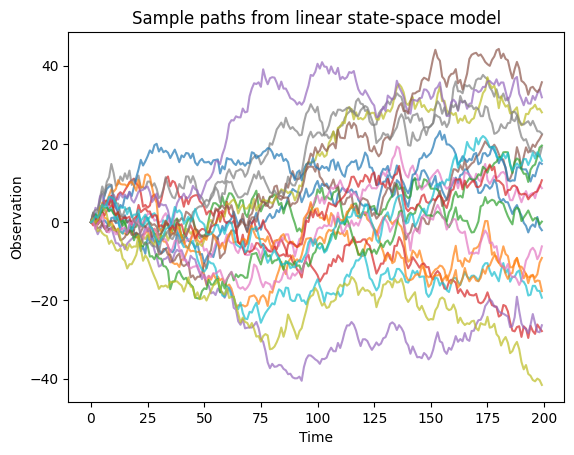

In [34]:
"""
Linear state-space model test / debug run
"""

T = 200
rng = np.random.default_rng(seed=42)
u = rng.normal(loc=0, scale=1, size=T)
theta = np.asarray([-1, 0.8])

n_paths = 20

for _ in range(n_paths):
    xs, ys = Svensson2017LinearSSM_simulate(u, theta, T, rng)
    plt.plot(ys, alpha=0.7)
    

plt.title("Sample paths from linear state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

Particle filter took 0.0033702850341796875s
PMMH took 1.0340526103973389s
Acceptance rate of initial PMMH sample: 0.9733333333333334


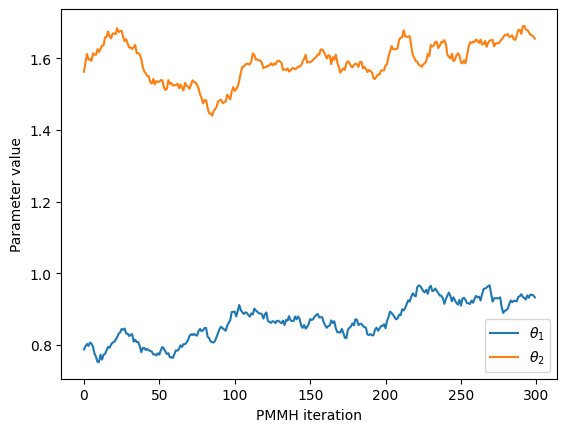

In [18]:
"""
PMMH test / debug run for nonlinear model
"""

""" Test whether the PMH sampling works by sampling
an intiial estimate from the posterior p(theta|y_1:T,temp)
"""

temp = 10 # Initial tempering
T = 100 # Number of observations

# True parameter
theta = np.asarray([1,1])

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = Svensson2017NonLinearSSM_simulate(theta=theta,T=T,u=u,rng=rng)

# Sample theta from parameter prior
theta = Svensson2017NonLinearSSM_sample_prior()

# Generate particle approximations for p(y_t|x_1:T,theta,temp)
# for the initial parameter sample
t0 = time.time()
xs, aas, log_lik = Svensson2017NonLinearSSM_bootstrap_pf(temp=temp,
                          n_particles=300,
                          ys=ys,
                          us=us,
                          theta=theta,
                          alternative_tempering=False
                          )
t1 = time.time()
print(f'Particle filter took {t1 - t0}s')

# Run PMH
t0 = time.time()

samples, xss, aass, log_liks, accept_rate = Svensson2017NonLinearSSM_pmmh(
    xs=xs,
    aas=aas,
    log_lik=log_lik,
    theta=theta,
    ys=ys,
    us=us,
    temp=temp,
    n_iters=300,
    proposal_sd=0.01,
    verbose=True,
    alternative_tempering=False
)
t1 = time.time()
print(f'PMMH took {t1 - t0}s')
print(f'Acceptance rate of initial PMMH sample: {accept_rate}')

# Plot result
plt.plot(samples[:,0],label=r'$\theta_1$')
plt.plot(samples[:,1],label=r'$\theta_2$')
plt.xlabel('PMMH iteration')
plt.ylabel('Parameter value')
plt.legend()

Starting Metropolis-Hastings run
                 Parameters: 
                 initial position = [ 0.25008151 -0.45376311]
                 tempering        = 1
                 iterations       = 300
                 proposal_sd      = 0.4
Finished Metropolis-Hastings run 
                 Acceptance rate: 0.20666666666666667
MH took 315.91270184516907s
Acceptance rate of initial MH sample: 0.9733333333333334


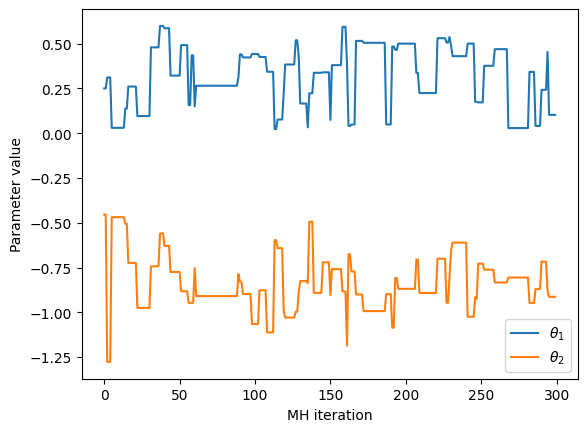

In [28]:
"""
MH test / debug run for linear model
"""

""" Test whether the MH sampling works by sampling
an intiial estimate from the posterior p(theta|y_1:T,temp)
"""

temp = 1 # Initial tempering
T = 200 # Number of observations

# True parameter
theta = np.asarray([-1,0.8])

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = Svensson2017LinearSSM_simulate(theta=theta,T=T,u=us,rng=rng)

# Sample theta from parameter prior
theta = Svensson2017LinearSSM_sample_prior()

samples = Svensson2017LinearSSM_mh(
    initial_theta=theta,
    ys=ys,
    us=us,
    temp=temp,
    n_iters=300,
    proposal_sd=0.4,
    verbose=True
)
t1 = time.time()
print(f'MH took {t1 - t0}s')
print(f'Acceptance rate of initial MH sample: {accept_rate}')

# Plot result
plt.plot(samples[:,0],label=r'$\theta_1$')
plt.plot(samples[:,1],label=r'$\theta_2$')
plt.xlabel('MH iteration')
plt.ylabel('Parameter value')
plt.legend()

In [38]:
""" Test whether SMC sampler works for the nonlinear model
"""

temp = 10.0 # Initial tempering
T = 200 # Number of observations
                              
theta = np.asarray([1,1]) # True parameter                              

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
_, ys = Svensson2017NonLinearSSM_simulate(T=T,theta=theta,u=us,rng=rng)

samples, records = Svensson2017NonLinearSSM_smc(
    ys=ys,
    us=us,
    initial_mh_iters=300,
    initial_mh_sd=0.5,
    mh_iters=10,
    mh_sd=0.1,
    n_sample_particles=100,
    n_filter_particles=300,
    temp=temp,
    min_temp=0.01,
    alpha=0.4,
    verbose=True,
    alternative_tempering=False,
    adaptive_pmh=False
)

New iteration: p = 1
Starting bisection...
Updated temperature, new temperature is: 9.579964523315427
Bisection took 1.220587968826294s
Starting mutation...
Finished mutation. Mutation took 0.880577564239502s
Mean accept rate: 0.7539999999999999
New iteration: p = 2
Starting bisection...
Updated temperature, new temperature is: 9.202341106303503
Bisection took 1.038778305053711s
Starting mutation...
Finished mutation. Mutation took 0.7614941596984863s
Mean accept rate: 0.7589999999999999
New iteration: p = 3
Starting bisection...
Updated temperature, new temperature is: 8.815212483052196
Bisection took 0.916987419128418s
Starting mutation...
Finished mutation. Mutation took 0.7811293601989746s
Mean accept rate: 0.7589999999999999
New iteration: p = 4
Starting bisection...
Updated temperature, new temperature is: 8.431892304613662
Bisection took 1.1479847431182861s
Starting mutation...
Finished mutation. Mutation took 0.7759649753570557s
Mean accept rate: 0.7440000000000001
New iteratio

KeyboardInterrupt: 